## Capstone Project

# Smart Resume Screener & Job Recommendation Portal

**AIM:**


To build an intelligent and user-friendly web application
that automatically analyzes uploaded resumes using NLP-driven Machine Learning
models and identifies the most suitable job roles for each candidate. Along with
predicting role fit, the system recommends relevant job openings from the
database and highlights key strengths and skill gaps, helping users improve their
career readiness.

This dual-purpose platform not only assists HR professionals by automating the
initial screening process but also empowers job seekers with personalized career
insights, making the hiring process smarter, faster, and more effective for both
sides.

**Import libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

**Load dataset**

In [2]:
df = pd.read_csv("job_roles.csv")
df.head()

,Job Title,Category,Education Requirement,Experience Years,Required Skills,Salary Range
0,Software Engineer,Technology,Bachelor's in Computer Science|Bachelor's in E...,2,Python|Java|C++|Git|Software Design|Problem So...,80-150K
1,Full Stack Developer,Technology,Diploma in IT|Bachelor's in Computer Science,2,JavaScript|React|Node.js|HTML/CSS|Database|Git,75-140K
2,Frontend Developer,Technology,Diploma in IT|Bachelor's in Computer Science,1,JavaScript|React|Vue.js|CSS|HTML|UI/UX Design,70-130K
3,Backend Developer,Technology,Bachelor's in Computer Science,2,Python|Java|Node.js|Database Design|API Develo...,75-135K
4,DevOps Engineer,Technology,Bachelor's in Computer Science|IT Certification,3,Docker|Kubernetes|AWS|Linux|CI/CD|Scripting,85-150K


In [3]:
df.tail()

,Job Title,Category,Education Requirement,Experience Years,Required Skills,Salary Range
319,Museum Curator,Arts & Culture,Master's in Art History|Museum Studies,3,Curation|Art Knowledge|Research|Communication|...,55-100K
320,Conservator,Arts & Culture,Master's in Conservation,2,Conservation|Restoration|Technical Skills|Prec...,55-100K
321,Exhibition Designer,Arts & Culture,Bachelor's in Design|Museum Studies,2,Exhibition Design|Creativity|Technical Skills|...,50-90K
322,Veterinarian,Veterinary,Doctor of Veterinary Medicine,1,Veterinary Medicine|Animal Care|Diagnosis|Comm...,80-150K
323,Veterinary Technician,Veterinary,Associate in Veterinary Technology,1,Veterinary Care|Animal Handling|Technical Skil...,35-60K


**Understand the data**

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Job Title              324 non-null    str  
 1   Category               324 non-null    str  
 2   Education Requirement  324 non-null    str  
 3   Experience Years       324 non-null    int64
 4   Required Skills        324 non-null    str  
 5   Salary Range           324 non-null    str  
dtypes: int64(1), str(5)
memory usage: 15.3 KB


In [5]:
df.shape

(324, 6)

In [9]:
df.describe()

,Experience Years
count,324.000000
mean,2.120370
std,1.733217
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,10.000000


### Observation: Descriptive Statistics Analysis

- The dataset contains 324 records,8 features.
- The presence of a few highly experienced candidates (up to 10 years) may introduce outliers but provides some representation of senior profiles.
- The average experience of candidates is approximately 2.12 years, indicating that most candidates are early-career professionals.
- The average resume text length is approximately 80.87 words/units.

In [10]:
df.describe(include='O').T

C:\Users\user\AppData\Local\Temp\ipykernel_7492\800431826.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='O').T


,count,unique,top,freq
Job Title,324,324,Software Engineer,1
Category,324,42,Technology,82
Education Requirement,324,245,Bachelor's in Computer Science,38
Required Skills,324,324,Python|Java|C++|Git|Software Design|Problem So...,1
Salary Range,324,90,70-130K,33


**Data cleaning**

In [5]:
#Check Missing Values
df.isnull().sum()   #if get missing val,then  df.dropna(inplace=True)

Job Title                0
Category                 0
Education Requirement    0
Experience Years         0
Required Skills          0
Salary Range             0
dtype: int64

In [51]:
#Check Duplicate Resumes
df.duplicated().sum()  #if get duplicate val,then df.drop_duplicates(inplace=True)

0

In [6]:
df['Job Title'].value_counts()

Job Title
Software Engineer        1
Full Stack Developer     1
Frontend Developer       1
Backend Developer        1
DevOps Engineer          1
                        ..
Museum Curator           1
Conservator              1
Exhibition Designer      1
Veterinarian             1
Veterinary Technician    1
Name: count, Length: 324, dtype: int64

### observation-Data cleaning

- There is no missing values
- There is no dulpicate data

## Visualization

**Job Roles Distribution**

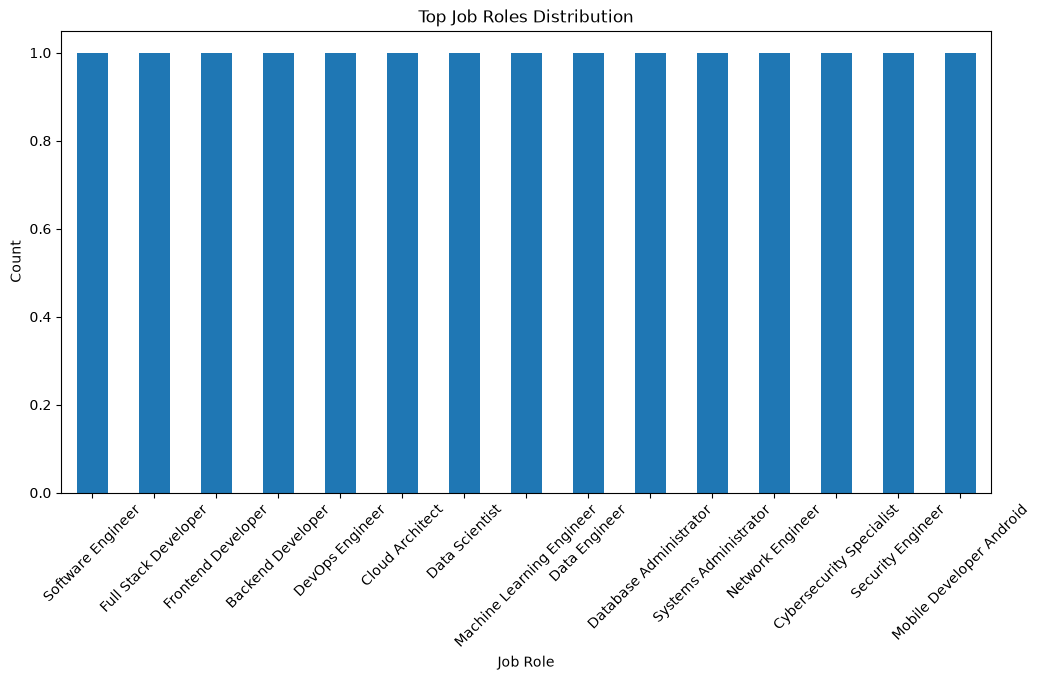

In [4]:
plt.figure(figsize=(12,6))
df['Job Title'].value_counts().head(15).plot(kind='bar')
plt.title("Top Job Roles Distribution")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Observation: Top Job Roles Distribution

- This graph shows the distribution of different job roles in the dataset.
  - X-axis: Job Roles (Job Titles)
  - Y-axis: Count (number of records for each role)
- All displayed job roles have equal frequency.Every job role has a count of 1.
- This means each role appears only once in the dataset.

**Job Category Distribution**

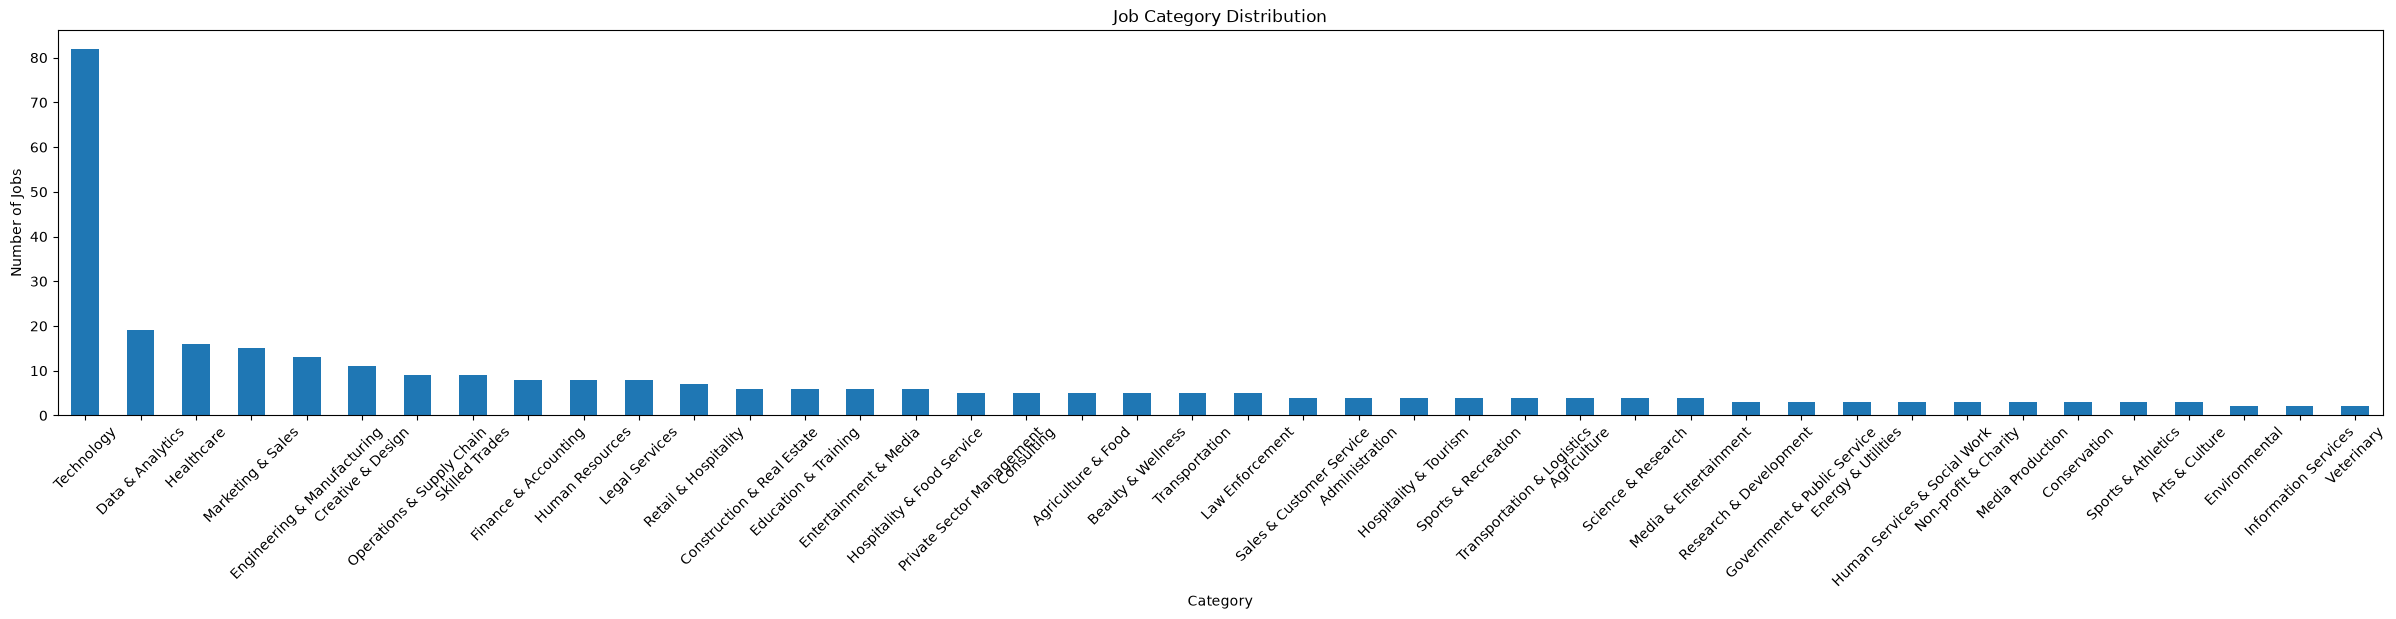

In [5]:
plt.figure(figsize=(30,5))
df['Category'].value_counts().plot(kind='bar')
plt.title("Job Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)

plt.show()

### Observation: Job Category Distribution

- This graph represents the distribution of job categories in the dataset.
  - X-axis: Job Categories
  - Y-axis: Number of Jobs (count of records)
- Technology category has the highest number of jobs.The Technology category has the largest count (around 80+ jobs).
- This indicates that the dataset contains more technology-related job opportunities compared to other fields.

**Experience Years Distribution**

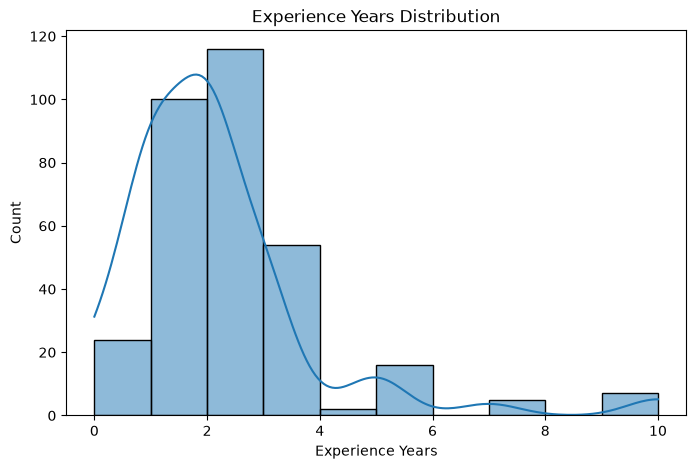

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Experience Years'],bins=10,kde=True)
plt.title("Experience Years Distribution")

plt.show()

### Observation: Experience Years Distribution

- Candidates with 2–3 years of experience form the largest group
- Very few candidates have 7–10 years of experience, indicating limited representation of senior-level candidates.
- The distribution is right-skewed (positively skewed) because most values are concentrated on the lower experience range, with a long tail toward     higher experience years.
- This suggests the dataset is more suitable for predicting entry-level and mid-level job categories rather than senior positions.


In [5]:
from collections import Counter

skills = " ".join(df['Required Skills'])
words = skills.split()
word_count = Counter(words)
common_words = word_count.most_common(15)
pd.DataFrame(common_words,columns=['Skill','Frequency'])

,Skill,Frequency
0,Solving,41
1,to,22
2,Detail,13
3,Skills,13
4,Knowledge,12
5,Management,11
6,Knowledge|Problem,11
7,Design,10
8,Strategic,10
9,Development,10


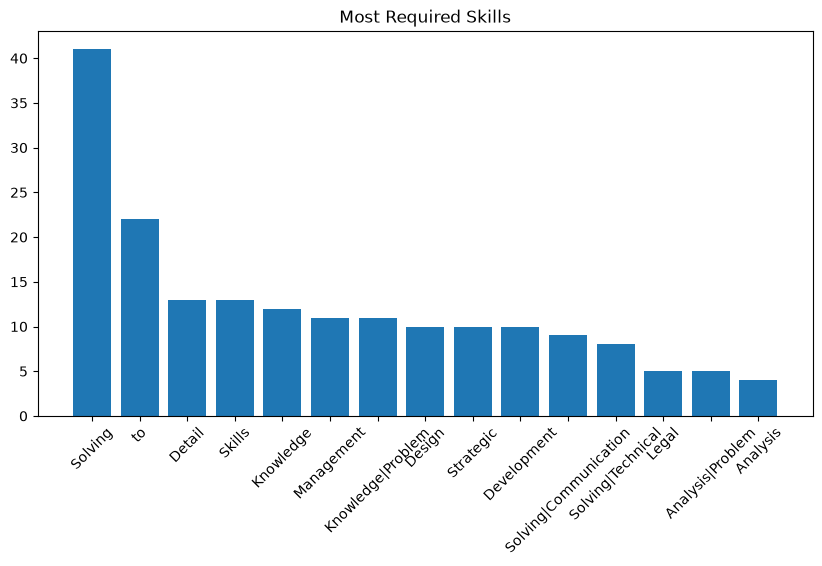

In [14]:
skill_df = pd.DataFrame(common_words,columns=['Skill','Frequency'])
plt.figure(figsize=(10,5))
plt.bar(skill_df['Skill'],skill_df['Frequency'])
plt.title("Most Required Skills")
plt.xticks(rotation=45)

plt.show()

**combine columns**

In [6]:
df['Job_Text'] = (df['Job Title'] + " " +df['Category'] + " " +df['Required Skills'])
df[['Job_Text','Job Title']].head()

,Job_Text,Job Title
0,Software Engineer Technology Python|Java|C++|G...,Software Engineer
1,Full Stack Developer Technology JavaScript|Rea...,Full Stack Developer
2,Frontend Developer Technology JavaScript|React...,Frontend Developer
3,Backend Developer Technology Python|Java|Node....,Backend Developer
4,DevOps Engineer Technology Docker|Kubernetes|A...,DevOps Engineer


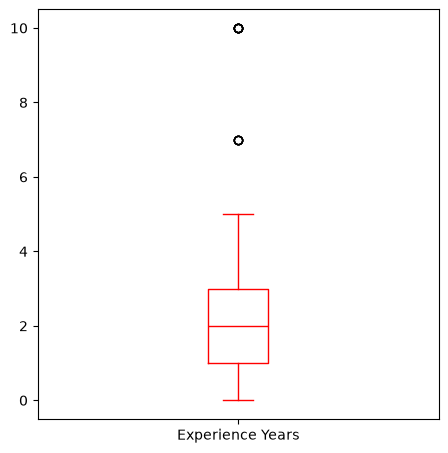

In [7]:
df.plot(kind='box',subplots=True,layout=(8,5),figsize=(30,50),color='red')
plt.title('boxplots of data set features')
plt.show()

### Boxplot Analysis (Experience Years & Text Length)

1. Experience Years

- The boxplot shows that most candidates have experience values between approximately 1 and 3 years.
- The median experience is around 2 years, indicating that the dataset mainly contains early-career candidates.
- The range extends from 0 to 5 years for most data points.
- There are some outliers at 7 and 10 years, representing candidates with significantly higher experience compared to the majority.
- The presence of these outliers indicates fewer senior-level candidates in the dataset.

2. Resume Text Length
   
- Resume text length is mostly concentrated between approximately 75 and 90 words/units.
- The median text length is around 82, showing that most resumes have similar content sizes.
- Some resumes have shorter text lengths (around 40–50), appearing as lower outliers.
- A few resumes have very long text lengths (above 120), appearing as upper outliers.
- The variation suggests differences in resume detail levels among candidates.
- The outliers may represent resumes with either incomplete information or highly detailed professional profiles.


# FEATURE ENGINEERING

## TF-IDF Conversion

- Resume and job description text data cannot be directly given to the ML model. 
- Text features are converted into numerical form using TF-IDF (Term Frequency–Inverse Document Frequency).

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df['Job_Text']
y = df['Category']

tfidf = TfidfVectorizer(stop_words='english',ngram_range=(1,2),max_features=20000)

X_vector = tfidf.fit_transform(X)

In [9]:
print(X_vector)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7511 stored elements and shape (324, 3314)>
  Coords	Values
  (0, 2651)	0.4083507674274557
  (0, 1034)	0.1637045881016427
  (0, 2941)	0.11273667701682508
  (0, 2237)	0.1972499204213814
  (0, 1410)	0.22197167618590044
  (0, 1231)	0.2751397699869157
  (0, 830)	0.14095844070796096
  (0, 2147)	0.09127355369311169
  (0, 2669)	0.09127355369311169
  (0, 2657)	0.2947625314681922
  (0, 1040)	0.20417538371372784
  (0, 2983)	0.22767186682871485
  (0, 2244)	0.2751397699869157
  (0, 1413)	0.2947625314681922
  (0, 1232)	0.2947625314681922
  (0, 2656)	0.2947625314681922
  (0, 856)	0.26121719914845354
  (0, 2148)	0.09127355369311169
  (1, 2941)	0.09983949128203314
  (1, 1231)	0.24366351212258644
  (1, 2766)	0.2610414105641641
  (1, 879)	0.1205857037488274
  (1, 1419)	0.1808175208078045
  (1, 2281)	0.23133369695832823
  (1, 1911)	0.23133369695832823
  :	:
  (322, 407)	0.24009033953832512
  (322, 917)	0.24009033953832512
  (322, 534)	0.224107

## Train-Test Split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X_vector,y,test_size=0.2,random_state=42)


## Model selection

## KNeighborsClassifier

Here, selected `KNeighborsClassifier` because resume screening is fundamentally a similarity-based problem. 
After converting resumes into TF-IDF vectors, KNN identifies the most similar resumes in the dataset and 
predicts the job category based on the nearest neighbors. It also supports job recommendations by using those nearest resumes,
making it well-suited for my Smart Resume Screener & Job Recommendation Portal with a dataset of 324 resumes.

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_vector,y)

prediction = knn.predict(X_test)

accuracy = accuracy_score( y_test,prediction)
print("Accuracy:",accuracy)

Accuracy: 0.9384615384615385


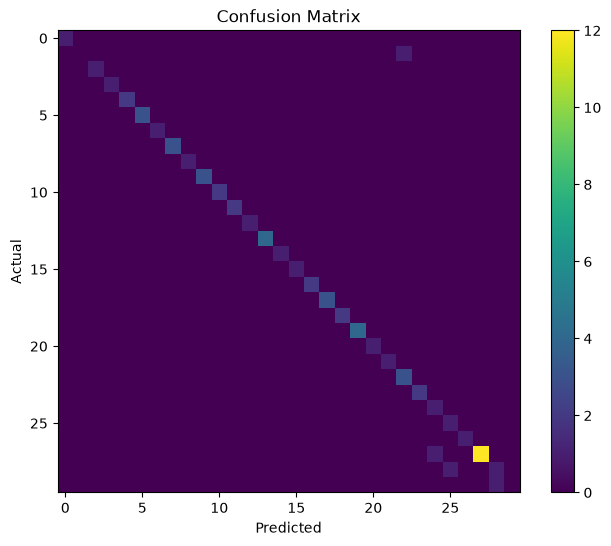

In [17]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test,prediction)
plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

**classification report**

In [18]:
report = classification_report(y_test, prediction)
print("Classification Report:")
print(report)

Classification Report:
                              precision    recall  f1-score   support

              Administration       1.00      1.00      1.00         1
                 Agriculture       0.00      0.00      0.00         1
          Agriculture & Food       1.00      1.00      1.00         1
              Arts & Culture       1.00      1.00      1.00         1
           Beauty & Wellness       1.00      1.00      1.00         2
  Construction & Real Estate       1.00      1.00      1.00         3
                  Consulting       1.00      1.00      1.00         1
           Creative & Design       1.00      1.00      1.00         3
            Data & Analytics       1.00      1.00      1.00         1
 Engineering & Manufacturing       1.00      1.00      1.00         3
       Entertainment & Media       1.00      1.00      1.00         2
               Environmental       1.00      1.00      1.00         2
        Finance & Accounting       1.00      1.00      1.00       

C:\Users\user\Documents\my_python\tf311_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\Documents\my_python\tf311_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\Documents\my_python\tf311_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

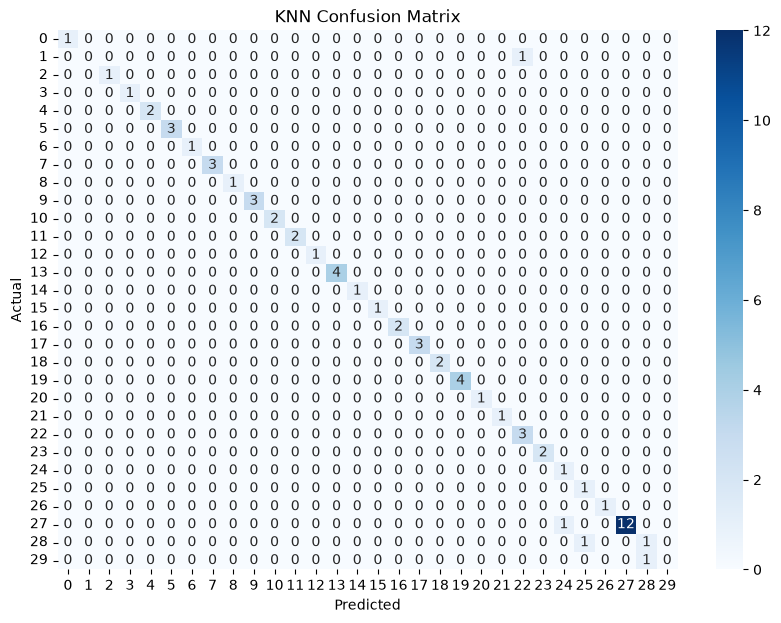

In [19]:
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

## Observation of KNN Model Performance

- The model achieved an `accuracy of 94%`, indicating that it correctly classified 94% of the test samples.
- The weighted average precision (0.93), weighted average recall (0.94), and weighted average F1-score (0.93) show that the model performs    consistently well across the dataset.
- The macro average F1-score of 0.89 indicates good overall performance across all categories, although a few classes have lower performance.

- Most job categories such as Technology, Healthcare, Marketing & Sales, Engineering & Manufacturing, Legal Services, and Creative & Design achieved precision, recall, and F1-scores close to or equal to 1.00, indicating excellent classification.
- Agriculture and Transportation & Logistics recorded 0.00 precision, recall, and F1-score, meaning the model failed to correctly classify these categories.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import pandas as pd

# Split the data
X_train,X_test,y_train,y_test = train_test_split(X_vector,y,test_size=0.2,random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_vector,y)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

# Display results
results_df = pd.DataFrame(results,columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy",ascending=False)

print(results_df)

                 Model  Accuracy
2        Decision Tree  1.000000
3        Random Forest  1.000000
5           Linear SVM  1.000000
1                  KNN  0.938462
0  Logistic Regression  0.584615
4          Naive Bayes  0.369231


**model saving**

In [ ]:
import os
import pickle

path = r"D:\capstone_project\model"

# create folder if not exists
os.makedirs(path, exist_ok=True)

# save KNN model
pickle.dump(knn,open(os.path.join(path,"knn_model.pkl"),"wb"))
# save TF-IDF
pickle.dump(tfidf,open(os.path.join(path,"tfidf.pkl"),"wb"))
print("Models saved successfully")